# Iris 데이터셋을 활용한 의사결정트리 및 랜덤포레스트 분류

## 과제 목표
Iris 데이터셋을 이용하여 다음 과정을 수행합니다.

1. Iris 데이터셋 확인
2. 데이터 전처리
3. 학습 데이터와 테스트 데이터 분리
4. 의사결정트리 학습
5. 의사결정트리 정확도 측정
6. 랜덤포레스트 학습
7. 랜덤포레스트 정확도 측정
8. 두 모델의 성능 비교
9. 의사결정트리 구조 시각화
10. 랜덤포레스트의 특성 중요도 시각화

**사용 라이브러리:** scikit-learn, pandas, matplotlib, seaborn


## 1. Iris 데이터셋 확인

`scikit-learn`에서 제공하는 Iris 데이터셋을 불러옵니다.

- 총 150개의 데이터
- 입력 특성 4개
  - 꽃받침 길이 (sepal length)
  - 꽃받침 너비 (sepal width)
  - 꽃잎 길이 (petal length)
  - 꽃잎 너비 (petal width)
- 분류 대상 3개
  - setosa
  - versicolor
  - virginica


In [2]:
# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Iris 데이터셋 불러오기
iris = load_iris()

# DataFrame 생성
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

# 데이터 확인
print("데이터 크기:", df.shape)
display(df.head())

print("\n특성 이름:")
print(iris.feature_names)

print("\n클래스 이름:")
print(iris.target_names)


데이터 크기: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



특성 이름:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

클래스 이름:
['setosa' 'versicolor' 'virginica']


## 2. 데이터 전처리

이번 실습의 Iris 데이터는 이미 수치형 특성으로 구성되어 있고 결측치가 없는 데이터이므로 복잡한 전처리가 필요하지 않습니다.

모델의 입력값 `X`와 정답값 `y`를 분리합니다.

- `X`: 꽃의 4가지 측정값
- `y`: 꽃의 종류를 나타내는 target


In [3]:
# 입력 데이터(X)와 정답 데이터(y) 분리
X = iris.data
y = iris.target

print("X의 형태:", X.shape)
print("y의 형태:", y.shape)

# 결측치 확인
print("\n결측치 개수:")
print(df.isnull().sum())


X의 형태: (150, 4)
y의 형태: (150,)

결측치 개수:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


## 3. 학습 데이터와 테스트 데이터 분리

전체 데이터 중 **80%는 학습용**, **20%는 테스트용**으로 사용합니다.

`stratify=y`를 사용하여 각 꽃 종류의 비율이 학습 데이터와 테스트 데이터에서 최대한 동일하게 유지되도록 합니다.

`random_state=42`를 지정하면 코드를 다시 실행해도 동일한 방식으로 데이터가 분할됩니다.


In [4]:
from sklearn.model_selection import train_test_split

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

print("\n학습 데이터 클래스별 개수:")
print(pd.Series(y_train).value_counts().sort_index())

print("\n테스트 데이터 클래스별 개수:")
print(pd.Series(y_test).value_counts().sort_index())


학습 데이터: (120, 4)
테스트 데이터: (30, 4)

학습 데이터 클래스별 개수:
0    40
1    40
2    40
Name: count, dtype: int64

테스트 데이터 클래스별 개수:
0    10
1    10
2    10
Name: count, dtype: int64


## 4. 의사결정트리 모델 학습

`DecisionTreeClassifier`를 이용하여 의사결정트리 모델을 생성하고 학습합니다.

`fit()` 메서드가 학습 데이터를 이용하여 모델을 학습하는 부분입니다.


In [5]:
from sklearn.tree import DecisionTreeClassifier

# 의사결정트리 모델 생성
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# 모델 학습
decision_tree.fit(X_train, y_train)

print("의사결정트리 모델 학습 완료")


의사결정트리 모델 학습 완료


## 5. 의사결정트리 정확도 측정

학습된 의사결정트리에 테스트 데이터를 입력하여 예측값을 구하고, 실제 정답과 비교하여 정확도를 계산합니다.

추가로 `classification_report`를 이용하여 precision, recall, f1-score도 확인합니다.


In [6]:
from sklearn.metrics import accuracy_score, classification_report

# 테스트 데이터 예측
dt_prediction = decision_tree.predict(X_test)

# 정확도 계산
dt_accuracy = accuracy_score(y_test, dt_prediction)

print("===== 의사결정트리 평가 결과 =====")
print(f"정확도: {dt_accuracy:.4f}")

print("\n분류 성능:")
print(
    classification_report(
        y_test,
        dt_prediction,
        target_names=iris.target_names
    )
)


===== 의사결정트리 평가 결과 =====
정확도: 0.9333

분류 성능:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 6. 랜덤포레스트 모델 학습

`RandomForestClassifier`를 이용하여 랜덤포레스트 모델을 생성하고 학습합니다.

랜덤포레스트는 여러 개의 결정트리를 구성한 뒤 그 결과를 종합하여 예측하는 앙상블 학습 방법입니다.

`n_estimators=100`은 100개의 결정트리를 사용한다는 의미입니다.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# 랜덤포레스트 모델 생성
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 모델 학습
random_forest.fit(X_train, y_train)

print("랜덤포레스트 모델 학습 완료")


랜덤포레스트 모델 학습 완료


## 7. 랜덤포레스트 정확도 측정

학습된 랜덤포레스트 모델로 테스트 데이터를 예측하고 정확도와 분류 성능을 확인합니다.


In [8]:
# 테스트 데이터 예측
rf_prediction = random_forest.predict(X_test)

# 정확도 계산
rf_accuracy = accuracy_score(y_test, rf_prediction)

print("===== 랜덤포레스트 평가 결과 =====")
print(f"정확도: {rf_accuracy:.4f}")

print("\n분류 성능:")
print(
    classification_report(
        y_test,
        rf_prediction,
        target_names=iris.target_names
    )
)


===== 랜덤포레스트 평가 결과 =====
정확도: 0.9000

분류 성능:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 8. 두 모델의 성능 비교

의사결정트리와 랜덤포레스트의 테스트 데이터 정확도를 비교합니다.

정확도는 전체 테스트 데이터 중 모델이 올바르게 분류한 데이터의 비율입니다.


,모델,정확도
0,의사결정트리,0.933333
1,랜덤포레스트,0.900000


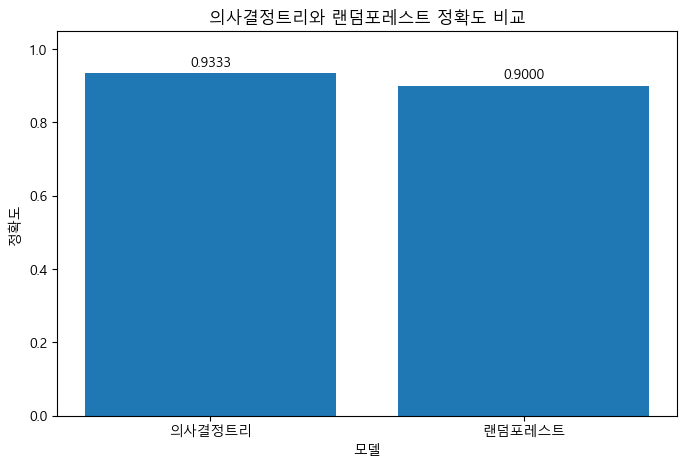

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

# 한글 폰트 설정

# Windows 기본 한글 폰트인 맑은 고딕 사용
plt.rcParams["font.family"] = "Malgun Gothic"

# 그래프에서 마이너스(-) 기호가 깨지는 것을 방지
plt.rcParams["axes.unicode_minus"] = False

# 모델별 정확도 비교
comparison = pd.DataFrame({
    "모델": ["의사결정트리", "랜덤포레스트"],
    "정확도": [dt_accuracy, rf_accuracy]
})

display(comparison)

# 정확도 시각화
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison["모델"],
    comparison["정확도"]
)

plt.ylim(0, 1.05)

plt.title("의사결정트리와 랜덤포레스트 정확도 비교")
plt.xlabel("모델")
plt.ylabel("정확도")


# 막대 위에 정확도 표시
for bar, value in zip(bars, comparison["정확도"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.show()

## 9. 의사결정트리 구조 시각화

학습된 의사결정트리가 어떤 기준으로 데이터를 분류하는지 시각적으로 확인합니다.

`plot_tree()`를 사용하면 각 노드의 분할 기준과 클래스 정보를 확인할 수 있습니다.

`max_depth=3`으로 표시 깊이를 제한하여 결과를 보기 쉽게 만들었습니다.


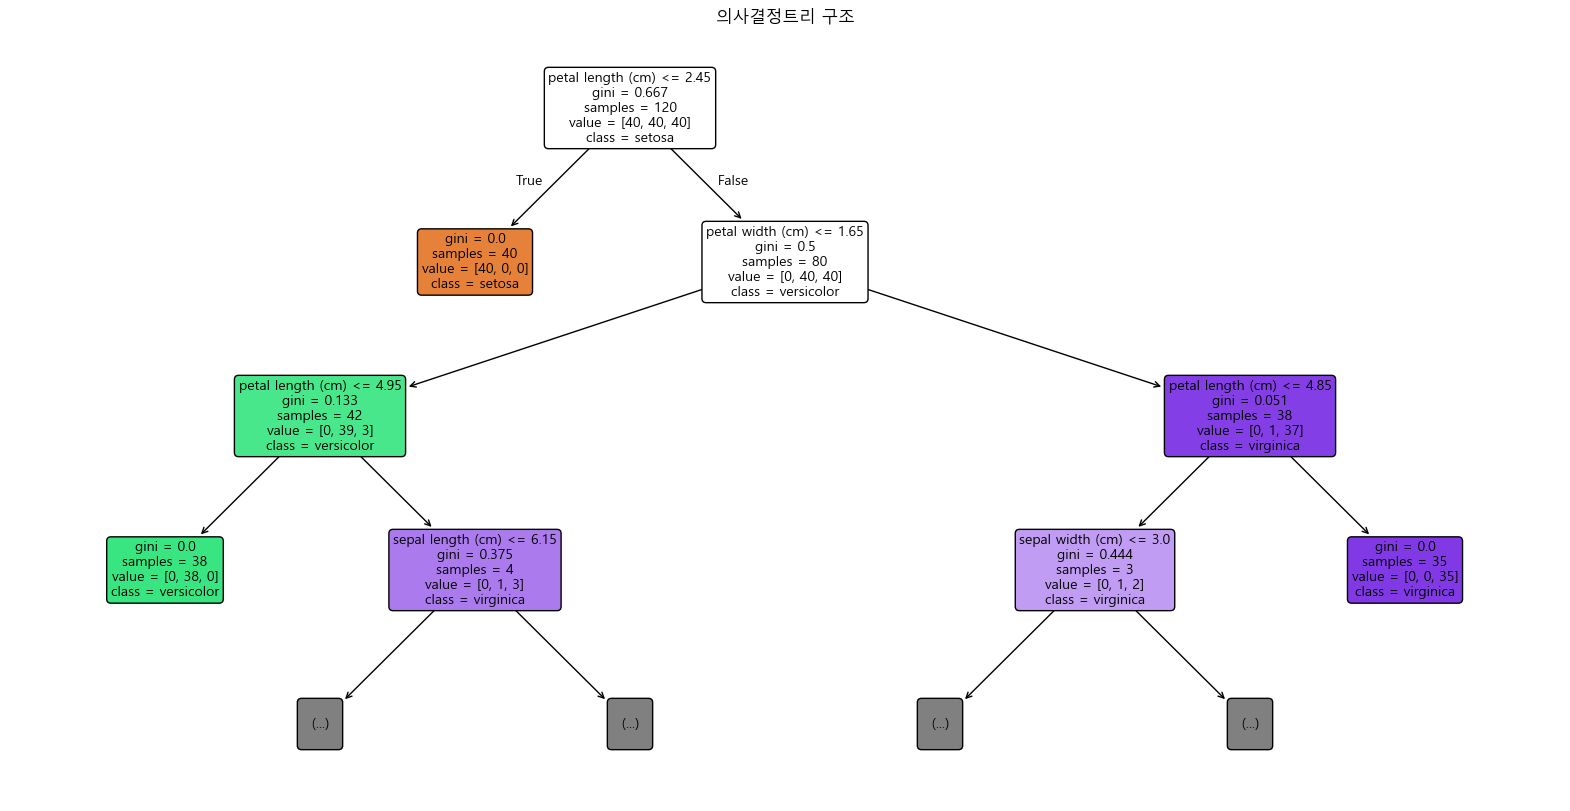

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("의사결정트리 구조")
plt.show()


## 10. 랜덤포레스트의 특성 중요도 시각화

랜덤포레스트는 각 특성이 분류에 얼마나 기여했는지를 나타내는 `feature_importances_` 값을 제공합니다.

값이 클수록 모델의 분류 과정에서 해당 특성이 상대적으로 많이 사용되었다는 의미입니다.

단, 특성 중요도는 **인과관계**를 의미하는 것이 아니라 모델의 예측 과정에서 사용된 상대적인 중요도를 나타냅니다.


,특성,중요도
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


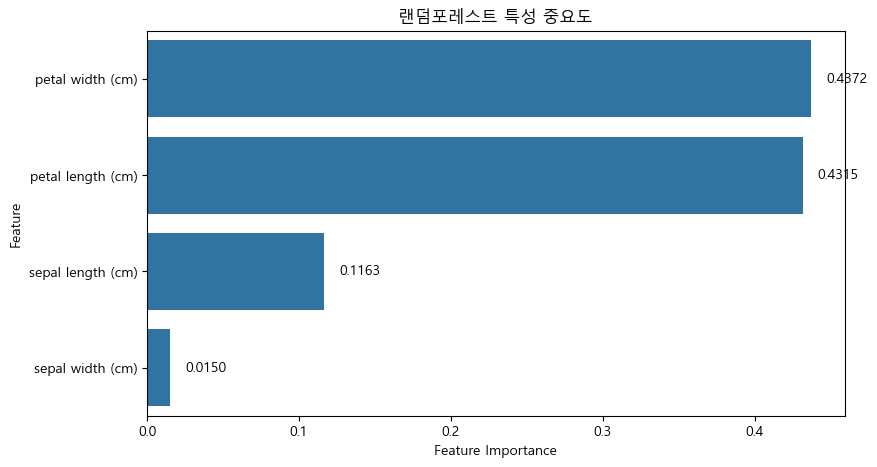

In [12]:
# 특성 중요도 추출
feature_importance = pd.DataFrame({
    "특성": iris.feature_names,
    "중요도": random_forest.feature_importances_
}).sort_values("중요도", ascending=False)

display(feature_importance)

# 특성 중요도 시각화
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="중요도",
    y="특성"
)

plt.title("랜덤포레스트 특성 중요도")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

# 값 표시
for i, value in enumerate(feature_importance["중요도"]):
    plt.text(value + 0.01, i, f"{value:.4f}", va="center")

plt.show()


# 최종 결과 요약

이번 실습에서는 Iris 데이터셋을 이용하여 두 가지 분류 모델을 학습했습니다.

### 사용한 모델
- **의사결정트리 (Decision Tree)**
- **랜덤포레스트 (Random Forest)**

### 수행한 과정
1. Iris 데이터셋을 불러왔습니다.
2. 입력 특성과 정답 데이터를 분리했습니다.
3. 학습 데이터와 테스트 데이터를 8:2로 분리했습니다.
4. 의사결정트리 모델을 학습했습니다.
5. 테스트 데이터로 의사결정트리의 성능을 평가했습니다.
6. 랜덤포레스트 모델을 학습했습니다.
7. 테스트 데이터로 랜덤포레스트의 성능을 평가했습니다.
8. 두 모델의 정확도를 비교했습니다.
9. 의사결정트리의 구조를 시각화했습니다.
10. 랜덤포레스트의 특성 중요도를 시각화했습니다.

> **참고:** 모델의 정확도는 데이터 분할 방식과 `random_state`, 라이브러리 버전에 따라 달라질 수 있습니다.
